# E-Commerce Sales Analysis

## Exploratory Data Analysis (EDA)

The objective of this analysis is to explore sales patterns,
product performance, customer locations, order status, and
revenue trends using the cleaned e-commerce dataset.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/amazon_cleaned.csv")

df.head()


Matplotlib is building the font cache; this may take a moment.


,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,Size,...,Qty,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by
0,405-8078784-5731545,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,S,...,0,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,No Promotion,False,Easy Ship
1,171-9198151-1101146,2022-04-30,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,3XL,...,1,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship
2,404-0687676-7273146,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,XL,...,1,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,Not Specified
3,403-9615377-8133951,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,L,...,0,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,No Promotion,False,Easy Ship
4,407-1069790-7240320,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,3XL,...,1,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,No Promotion,False,Not Specified


In [2]:
df.shape

(121149, 22)

In [3]:
df["Amount"].describe()

count    121149.000000
mean        648.573305
std         281.222115
min           0.000000
25%         449.000000
50%         605.000000
75%         788.000000
max        5584.000000
Name: Amount, dtype: float64

In [4]:
df[df["Amount"] == 0][["Order ID", "Status", "Qty", "Amount", "Category"]]

,Order ID,Status,Qty,Amount,Category
201,408-4547464-4180323,Shipped - Delivered to Buyer,1,0.0,kurta
356,408-5020509-5674715,Shipped - Returned to Seller,1,0.0,Western Dress
366,408-3137526-3167563,Shipped,1,0.0,kurta
369,408-7971979-8745937,Shipped - Delivered to Buyer,1,0.0,Western Dress
373,408-0912805-7526753,Shipped,1,0.0,Set
...,...,...,...,...,...
120749,408-6490796-0249925,Shipped,1,0.0,Set
120808,408-9074023-7691550,Shipped - Delivered to Buyer,1,0.0,Bottom
120877,408-9473849-4953122,Shipped,1,0.0,Western Dress
120989,408-9579839-6574765,Shipped - Delivered to Buyer,1,0.0,Set


In [5]:
df["Amount"].eq(0).sum()

np.int64(2343)

In [6]:
df[df["Amount"] == 0]["Status"].value_counts()


Status
Shipped                          1518
Shipped - Delivered to Buyer      716
Shipped - Returned to Seller       51
Shipped - Picked Up                28
Pending                            17
Pending - Waiting for Pick Up       9
Shipped - Lost in Transit           2
Shipped - Returning to Seller       2
Name: count, dtype: int64

In [7]:
df[df["Amount"] == 0]["Category"].value_counts()

Category
Set              1013
kurta             858
Western Dress     231
Top               174
Ethnic Dress       32
Blouse             22
Bottom             12
Saree               1
Name: count, dtype: int64

In [8]:
df[df["Amount"] == 0]["Qty"].value_counts()

Qty
1    2343
Name: count, dtype: int64

In [9]:
df[df["Amount"] == 0]["promotion-ids"].notna().value_counts()

promotion-ids
True    2343
Name: count, dtype: int64

In [10]:
df[df["Amount"] == 0][["Amount", "promotion-ids", "Status", "Category"]].head(20)

,Amount,promotion-ids,Status,Category
201,0.0,Amazon PLCC Free-Financing Universal Merchant ...,Shipped - Delivered to Buyer,kurta
356,0.0,Amazon PLCC Free-Financing Universal Merchant ...,Shipped - Returned to Seller,Western Dress
366,0.0,No Promotion,Shipped,kurta
369,0.0,Amazon PLCC Free-Financing Universal Merchant ...,Shipped - Delivered to Buyer,Western Dress
373,0.0,No Promotion,Shipped,Set
415,0.0,No Promotion,Shipped,Set
420,0.0,Amazon PLCC Free-Financing Universal Merchant ...,Shipped - Delivered to Buyer,Set
425,0.0,No Promotion,Shipped,Set
427,0.0,No Promotion,Shipped,Set
679,0.0,Amazon PLCC Free-Financing Universal Merchant ...,Shipped - Delivered to Buyer,Blouse


In [11]:
df[df["Amount"] == 0]["promotion-ids"].value_counts().head(10)

promotion-ids
No Promotion                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              1562
Amazon PLCC Free-Financing Universal Merchant AAT-XXRCW6NZEPZI4,Amazon PLCC

In [12]:
pd.crosstab(
    df["Status"],
    df["Amount"].eq(0)
)

Amount,False,True
Status,,
Cancelled,10761,0
Pending,639,17
Pending - Waiting for Pick Up,272,9
Shipped,76062,1518
Shipped - Damaged,1,0
Shipped - Delivered to Buyer,28038,716
Shipped - Lost in Transit,3,2
Shipped - Out for Delivery,35,0
Shipped - Picked Up,945,28


### Zero Amount Investigation

There are 2,343 orders with an Amount of 0.

These records are not simply cancelled orders, as most have shipped or delivered statuses. 
Some contain promotional information, while 1,562 records have "No Promotion".

Therefore, zero-amount records are retained in the cleaned dataset. 
For revenue and sales-value analysis, only orders with Amount > 0 will be considered.

In [13]:
sales_df = df[df["Amount"] > 0].copy()

sales_df.shape

(118806, 22)

In [14]:
sales_df["Amount"].describe()

count    118806.000000
mean        661.363966
std         268.674911
min         199.000000
25%         458.000000
50%         622.000000
75%         788.000000
max        5584.000000
Name: Amount, dtype: float64

In [15]:
sales_df["Amount"].eq(0).sum()

np.int64(0)

In [16]:
sales_df["Amount"].sum()

np.float64(78574007.30000001)

In [17]:
sales_df["Order ID"].nunique()

110661

In [18]:
sales_df["Qty"].sum()

np.int64(114111)

In [19]:
sales_df["Amount"].sum() / sales_df["Order ID"].nunique()

np.float64(710.0424476554523)

In [20]:
category_sales = (
    sales_df.groupby("Category")["Amount"]
    .agg(["sum", "count", "mean"])
    .sort_values("sum", ascending=False)
)

category_sales

,sum,count,mean
Category,,,
Set,39195176.03,46018,851.735756
kurta,21291538.70,45842,464.454838
Western Dress,11215337.69,14472,774.968055
Top,5346812.30,9989,535.270027
Ethnic Dress,791217.66,1061,745.728238
Blouse,458408.18,859,533.653295
Bottom,150667.98,408,369.284265
Saree,123933.76,154,804.764675
Dupatta,915.00,3,305.000000


<Axes: title={'center': 'Revenue by Category'}, xlabel='Category'>

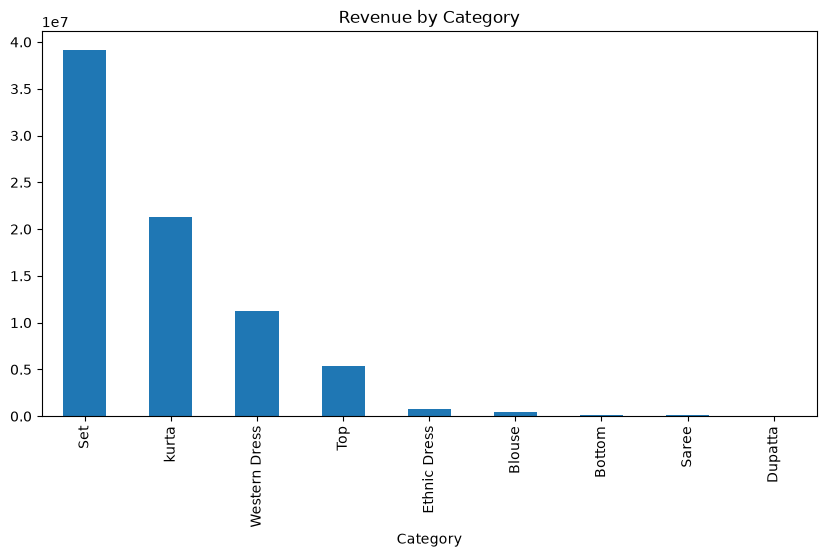

In [21]:
category_sales["sum"].plot(kind="bar", figsize=(10, 5), title="Revenue by Category")

In [22]:
state_sales = (
    sales_df.groupby("ship-state")["Amount"]
    .agg(["sum", "count", "mean"])
    .sort_values("sum", ascending=False)
)

state_sales.head(10)

,sum,count,mean
ship-state,,,
MAHARASHTRA,13335534.14,20639,646.132765
KARNATAKA,10481114.37,16064,652.459809
TELANGANA,6916615.65,10472,660.486598
UTTAR PRADESH,6816642.08,9708,702.167499
TAMIL NADU,6515650.11,10632,612.833908
DELHI,4235215.97,6222,680.684020
KERALA,3830227.58,6072,630.801644
WEST BENGAL,3507880.44,5437,645.186765
ANDHRA PRADESH,3219831.72,4993,644.869161


<Axes: title={'center': 'Top 10 States by Revenue'}, xlabel='ship-state'>

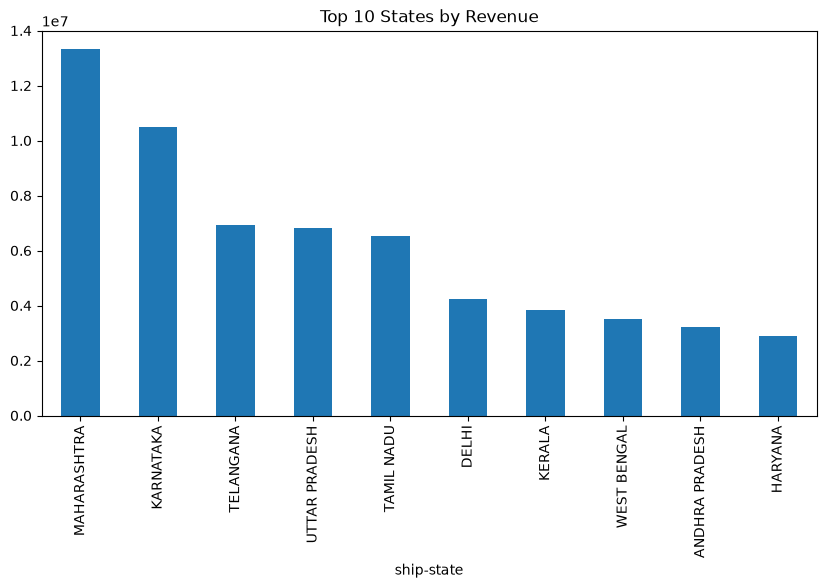

In [23]:
state_sales.head(10)["sum"].plot(
    kind="bar",
    figsize=(10, 5),
    title="Top 10 States by Revenue"
)

In [24]:
sales_df["Date"] = pd.to_datetime(sales_df["Date"])

In [25]:
monthly_sales = (
    sales_df
    .groupby(sales_df["Date"].dt.to_period("M"))["Amount"]
    .sum()
)

monthly_sales

Date
2022-03      101683.85
2022-04    28831249.32
2022-05    26219850.75
2022-06    23421223.38
Freq: M, Name: Amount, dtype: float64

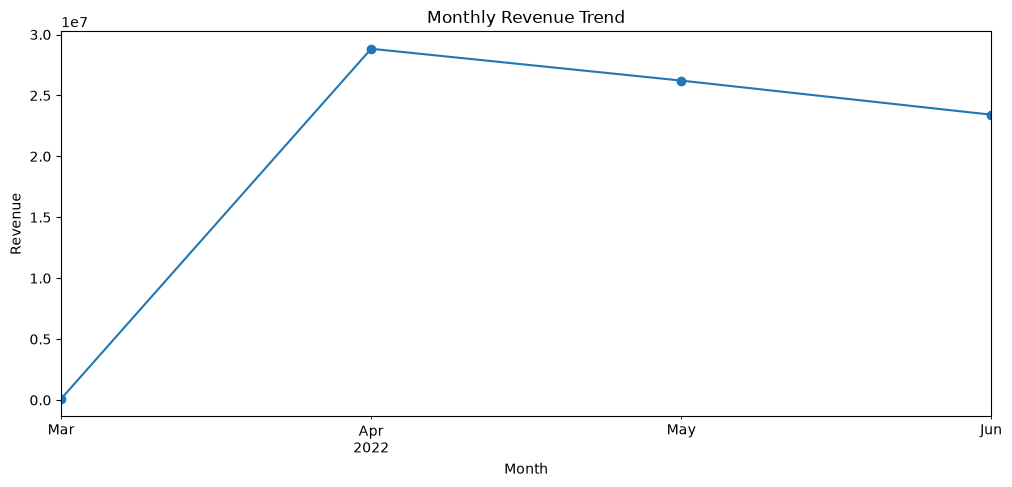

In [26]:
monthly_sales.plot(
    kind="line",
    figsize=(12, 5),
    marker="o",
    title="Monthly Revenue Trend"
)

plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

Observation:

Revenue increased sharply from March to April 2022, reaching its peak of approximately ₹2.88 crore. Revenue then declined gradually in May and June, indicating that April was the strongest sales month in the available dataset.

In [27]:
status_sales = sales_df["Status"].value_counts()

status_sales

Status
Shipped                          76062
Shipped - Delivered to Buyer     28038
Cancelled                        10761
Shipped - Returned to Seller      1896
Shipped - Picked Up                945
Pending                            639
Pending - Waiting for Pick Up      272
Shipped - Returning to Seller      143
Shipped - Out for Delivery          35
Shipped - Rejected by Buyer         11
Shipped - Lost in Transit            3
Shipped - Damaged                    1
Name: count, dtype: int64

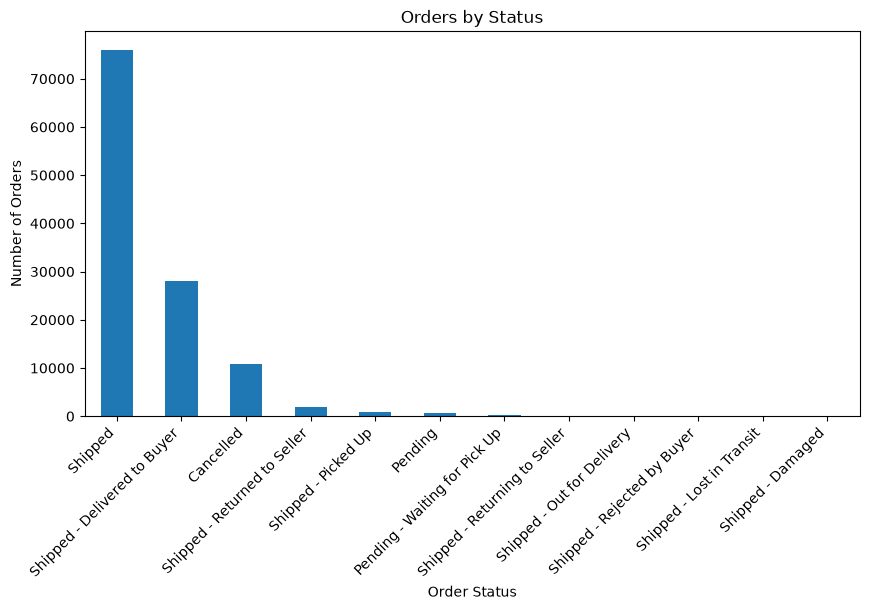

In [28]:
status_sales.plot(
    kind="bar",
    figsize=(10, 5),
    title="Orders by Status"
)

plt.xlabel("Order Status")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45, ha="right")
plt.show()

### Observation

Most orders are currently in the **Shipped** status (76,062), followed by **Shipped - Delivered to Buyer** (28,038). Cancelled orders account for 10,761 orders. Other statuses occur much less frequently, indicating that the majority of orders successfully progressed through the shipping process.

In [29]:
fulfilment_sales = sales_df["Fulfilment"].value_counts()

fulfilment_sales

Fulfilment
Amazon      82094
Merchant    36712
Name: count, dtype: int64

In [30]:
fulfilment_revenue = (
    sales_df.groupby("Fulfilment")["Amount"]
    .agg(["sum", "count", "mean"])
    .sort_values("sum", ascending=False)
)

fulfilment_revenue

,sum,count,mean
Fulfilment,,,
Amazon,54311285.0,82094,661.574354
Merchant,24262722.3,36712,660.893503


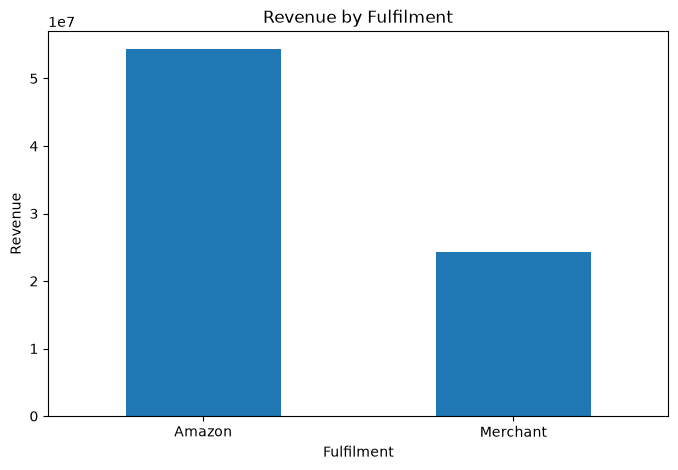

In [31]:
fulfilment_revenue["sum"].plot(
    kind="bar",
    figsize=(8, 5),
    title="Revenue by Fulfilment"
)

plt.xlabel("Fulfilment")
plt.ylabel("Revenue")
plt.xticks(rotation=0)
plt.show()

### Observation

Amazon fulfilment accounts for the majority of orders and revenue, with 82,094 orders generating approximately ₹5.43 crore. Merchant fulfilment accounts for 36,712 orders and approximately ₹2.43 crore. The average order value is almost identical for both fulfilment methods, at around ₹661 per order.

In [36]:
channel_sales = sales_df["Sales Channel "].value_counts()

channel_sales

Sales Channel 
Amazon.in    118806
Name: count, dtype: int64

In [38]:
channel_revenue = (
    sales_df.groupby("Sales Channel ")["Amount"]
    .agg(["sum", "count", "mean"])
    .sort_values("sum", ascending=False)
)

channel_revenue

,sum,count,mean
Sales Channel,,,
Amazon.in,78574007.3,118806,661.363966


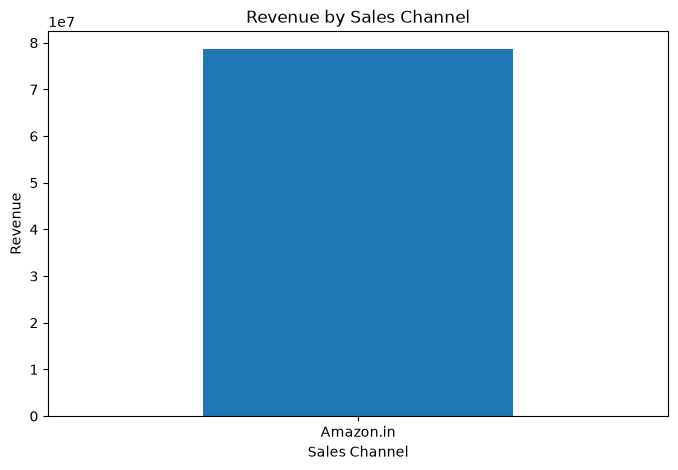

In [39]:
channel_revenue["sum"].plot(
    kind="bar",
    figsize=(8, 5),
    title="Revenue by Sales Channel"
)

plt.xlabel("Sales Channel")
plt.ylabel("Revenue")
plt.xticks(rotation=0)
plt.show()

category_qty = (
    sales_df.groupby("Category")["Qty"]
    .sum()
    .sort_values(ascending=False)
)

category_qty

### Observation

The dataset contains only one sales channel, **Amazon.in**, with 118,806 orders. It generated approximately **₹7.86 crore** in revenue, with an average order value of approximately **₹661.36**. Therefore, there is no meaningful sales-channel comparison possible within this dataset.

In [40]:
category_qty = (
    sales_df.groupby("Category")["Qty"]
    .sum()
    .sort_values(ascending=False)
)

category_qty

Category
Set              44201
kurta            44098
Western Dress    13707
Top               9723
Ethnic Dress      1021
Blouse             822
Bottom             385
Saree              151
Dupatta              3
Name: Qty, dtype: int64

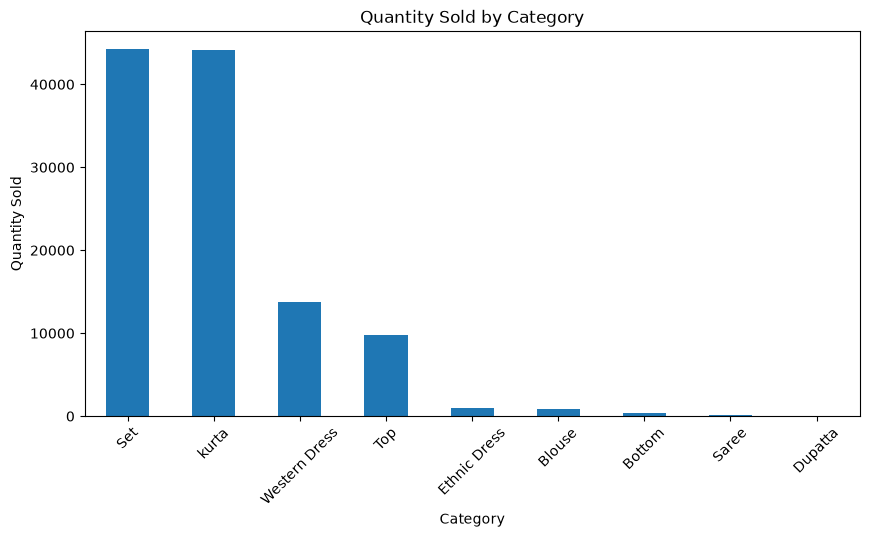

In [41]:
category_qty.plot(
    kind="bar",
    figsize=(10, 5),
    title="Quantity Sold by Category"
)

plt.xlabel("Category")
plt.ylabel("Quantity Sold")
plt.xticks(rotation=45)
plt.show()

### Observation

**Set** and **kurta** are the top-selling categories by quantity, with **44,201** and **44,098** units sold respectively. Together, they account for approximately **77% of the total quantity sold**. **Western Dress** and **Top** follow with 13,707 and 9,723 units respectively, while the remaining categories contribute relatively small quantities.

In [42]:
category_aov = (
    sales_df.groupby("Category")["Amount"]
    .mean()
    .sort_values(ascending=False)
)

category_aov

Category
Set              851.735756
Saree            804.764675
Western Dress    774.968055
Ethnic Dress     745.728238
Top              535.270027
Blouse           533.653295
kurta            464.454838
Bottom           369.284265
Dupatta          305.000000
Name: Amount, dtype: float64

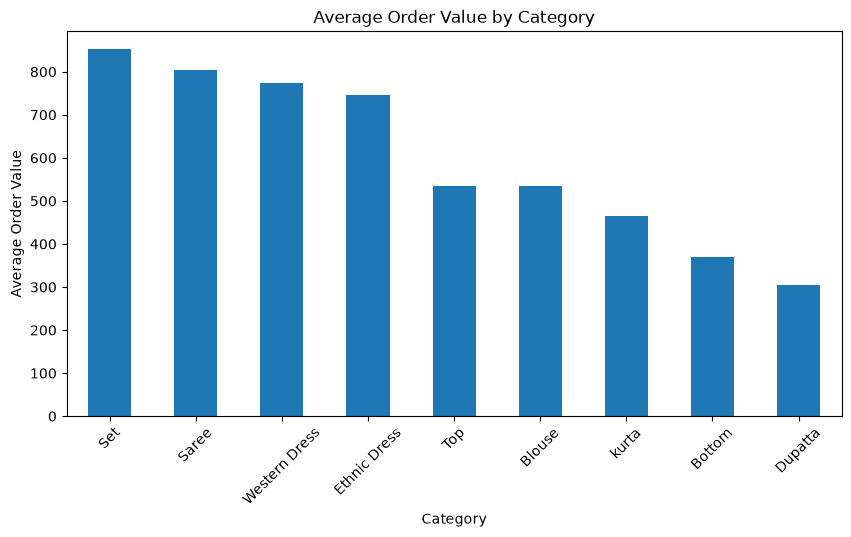

In [43]:
category_aov.plot(
    kind="bar",
    figsize=(10, 5),
    title="Average Order Value by Category"
)

plt.xlabel("Category")
plt.ylabel("Average Order Value")
plt.xticks(rotation=45)
plt.show()

### Observation

**Set** has the highest Average Order Value (AOV) at approximately **₹851.74**, followed by **Saree** at **₹804.76**. **Western Dress** and **Ethnic Dress** also show relatively high average order values. In contrast, **Dupatta** has the lowest AOV at approximately **₹305.00**. Although **kurta** is one of the highest-selling categories by quantity, its AOV is comparatively lower at approximately **₹464.45**.

In [44]:
top_products = (
    sales_df.groupby("SKU")["Qty"]
    .sum()
    .sort_values(ascending=False)
)

top_products.head(10)

SKU
JNE3797-KR-L       646
JNE3797-KR-M       546
JNE3797-KR-S       495
JNE3405-KR-L       471
J0230-SKD-M        453
J0230-SKD-S        415
JNE3797-KR-XL      410
JNE3405-KR-S       396
JNE3797-KR-XS      383
SET268-KR-NP-XL    366
Name: Qty, dtype: int64

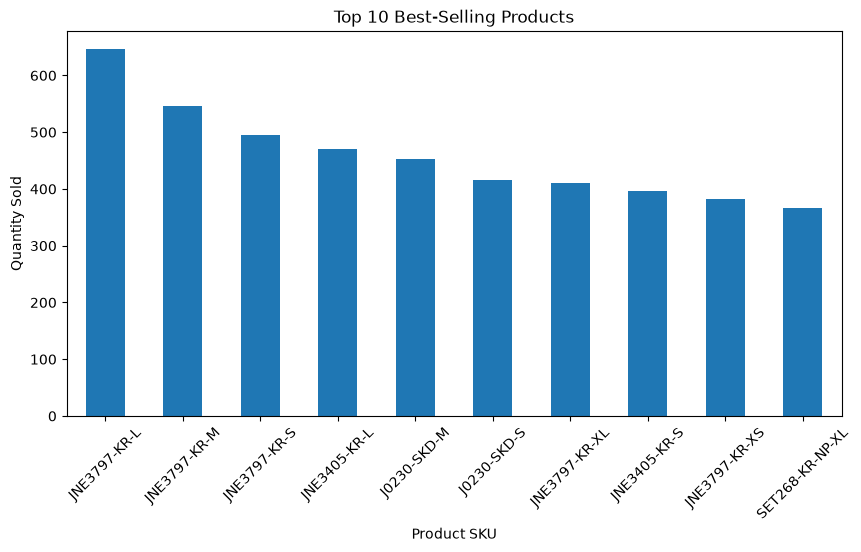

In [45]:
top_products.head(10).plot(
    kind="bar",
    figsize=(10, 5),
    title="Top 10 Best-Selling Products"
)

plt.xlabel("Product SKU")
plt.ylabel("Quantity Sold")
plt.xticks(rotation=45)
plt.show()

### Observation

The **JNE3797-KR-L** SKU is the best-selling product with **646 units sold**, followed by **JNE3797-KR-M** with 546 units and **JNE3797-KR-S** with 495 units. The JNE3797 product family appears prominently among the top-selling SKUs, indicating strong demand for this product line.

# Key Business Insights

1. **Strong overall sales performance:**  
   The dataset generated approximately **₹7.86 crore in total revenue** from **110,661 unique orders**, with an average revenue of approximately **₹710 per order**.

2. **Set is the leading revenue category:**  
   **Set** generated the highest revenue of approximately **₹3.92 crore**, followed by **kurta** at approximately **₹2.13 crore**. These two categories are the major contributors to overall revenue.

3. **Maharashtra is the top-performing region:**  
   **Maharashtra** generated the highest regional revenue at approximately **₹1.33 crore**, followed by Karnataka at approximately **₹1.05 crore**. This indicates strong demand in these markets.

4. **April 2022 was the strongest sales month:**  
   Revenue increased sharply from March to April 2022, reaching approximately **₹2.88 crore** in April. Revenue then declined gradually in May and June.

5. **Shipped orders dominate the order status:**  
   The **Shipped** status accounts for **76,062 orders**, while **28,038 orders** were marked as **Shipped - Delivered to Buyer**. This shows that the majority of orders progressed through the shipping process.

6. **Amazon fulfilment contributes the majority of revenue:**  
   Amazon fulfilment generated approximately **₹5.43 crore** in revenue from **82,094 orders**, considerably higher than Merchant fulfilment at approximately **₹2.43 crore**.

7. **JNE3797 product family shows strong demand:**  
   **JNE3797-KR-L** was the best-selling SKU with **646 units sold**, followed by JNE3797-KR-M and JNE3797-KR-S. Multiple variants of the JNE3797 product appear among the top-selling products, indicating strong demand for this product line.